In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hapi import *
db_begin('data');

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [54]:
getHelp(absorptionCoefficient_Voigt)

Help on function absorptionCoefficient_Voigt in module hapi.hapi:

absorptionCoefficient_Voigt(*args, **kwargs)
    INPUT PARAMETERS:
        Components:  list of tuples [(M,I,D)], where
                        M - HITRAN molecule number,
                        I - HITRAN isotopologue number,
                        D - relative abundance (optional)
        SourceTables:  list of tables from which to calculate cross-section   (optional)
        partitionFunction:  pointer to partition function (default is PYTIPS) (optional)
        Environment:  dictionary containing thermodynamic parameters.
                        'p' - pressure in atmospheres,
                        'T' - temperature in Kelvin
                        Default={'p':1.,'T':296.}
        WavenumberRange:  wavenumber range to consider.
        WavenumberStep:   wavenumber step to consider.
        WavenumberWing:   absolute wing for calculating a lineshape (in cm-1)
        WavenumberWingHW:  relative wing for calculat

In [64]:
# max_wavenumber = 1./(0.5e-6*1e2) # convert 0.5 microns to cm^{-1}
max_wavenumber = 1./(0.75e-6*1e2) # convert 0.5 microns to cm^{-1}
min_wavenumber = 1./(0.98e-6*1e2) # convert 0.5 microns to cm^{-1}
print(min_wavenumber, max_wavenumber)

fetch('H2O',1,1,min_wavenumber,max_wavenumber);

nu,coef = absorptionCoefficient_Voigt(SourceTables='H2O', Environment={'p':0.006,'T':215.}, Diluent={'CO2':1.0})
coef /= 1e4 # convert to m^2

# fetch('H2O',2,1,2000,2100)
# nu,coef = absorptionCoefficient_Lorentz(SourceTables='H2O', Diluent={'air':1.0})

10204.081632653062 13333.333333333332

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written to hapi_data/H2O.data
  65536 bytes written

1.3506663937238542e-05
325.0829490816197


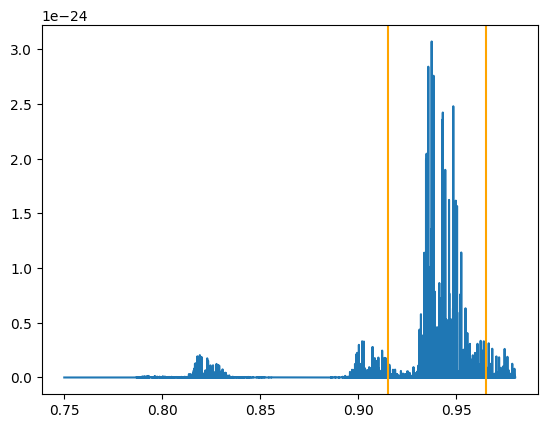

In [68]:
max_wavenumber = 1./(0.75e-6*1e2) # convert 0.5 microns to cm^{-1}
min_wavenumber = 1./(0.98e-6*1e2) # convert 0.5 microns to cm^{-1}
wavenumber_step = 0.01
T = 215. # K
P = 0.006

# fetch('H2O',1,1,min_wavenumber,max_wavenumber);

# nu, coef = absorptionCoefficient_Voigt(
#     SourceTables='H2O', 
#     WavenumberRange=(min_wavenumber, max_wavenumber),
#     Environment={'T': T, 'p': P},
#     HITRAN_units=True   
# )

# Convert to m^2/molec
# coef *= 1e-4

# Dust optical depth - https://pdf.sciencedirectassets.com/272593/1-s2.0-S0019103513X00041/1-s2.0-S0019103513000353/main.pdf
dust_extinction = 0.07/1e3 # per meter
dust_optical_depth = dust_extinction*altitude

Mars_density = 0.02/7.3080318e-26 # 1/m^3
water_fraction = 0.0003
water_number_density = Mars_density*water_fraction
altitude = 40. # m
water_optical_depth = water_number_density*altitude*coef
# print(water_number_density)

lamb = (1/nu/1e2)/1e-6
plt.plot(lamb, coef)

# Wavelengths from https://gemini.google.com/share/f1763edbeddb
v3HP_lamb = 905.e-9/1e-6
v4_lamb = 940.e-9/1e-6
# v4_lamb = 895.e-9/1e-6
bandwidth = 50e-9/1e-6

ind = np.abs(v4_lamb - lamb) <= 0.5*bandwidth
avg_tau = water_number_density*altitude*np.mean(coef[ind])
print(avg_tau)
# print(1./avg_tau**2)

repetition_frequency = 10e3 # 10 kHz
integration_time = 1. # seconds
number_of_measurements = repetition_frequency*integration_time

h = 6.62607015E-34
c = 299792458.
energy_per_photon = h*c/v4_lamb
energy_per_pulse = 270e-9 # from LIDAR-LITE V3
number_of_emerging_photons = energy_per_pulse/energy_per_photon

beam_divergence_angle = 8e-3 # radians -- from LIDAR-LITE V3
area_illuminated = np.pi*(beam_divergence_angle*altitude/2.)**2
surface_reflectance = 0.9 # Just a rough guess

# print(avg_tau)
inband_incident_photon_flux = number_of_emerging_photons/area_illuminated*(1 - avg_tau)*(1 - dust_optical_depth)
inband_reflected_photon_intensity = surface_reflectance*inband_incident_photon_flux/np.pi # dividing into steradians
inband_returning_photon_intensity = inband_reflected_photon_intensity*(1 - avg_tau)*(1 - dust_optical_depth)
inband_number_of_returning_photons = beam_divergence_angle**2*inband_returning_photon_intensity

# Same calculation but without gas optical depth
outband_incident_photon_flux = number_of_emerging_photons/area_illuminated*(1 - dust_optical_depth)
outband_reflected_photon_intensity = surface_reflectance*outband_incident_photon_flux/np.pi # dividing into steradians
outband_returning_photon_intensity = outband_reflected_photon_intensity*(1 - dust_optical_depth)
outband_number_of_returning_photons = beam_divergence_angle**2*outband_returning_photon_intensity

print((outband_number_of_returning_photons - inband_number_of_returning_photons)/\
          np.sqrt(outband_number_of_returning_photons + inband_number_of_returning_photons))

# plt.axvline(v3HP_lamb)
plt.axvline(v4_lamb - 0.5*bandwidth, color='orange')
plt.axvline(v4_lamb + 0.5*bandwidth, color='orange')
# plt.axvline(1.064)

# mn_ind = np.argmin(np.abs(v3HP_lamb - lamb))
# print(v3HP_lamb, water_optical_depth[mn_ind])

# mn_ind = np.argmin(np.abs(v4_lamb - lamb))
# print(v4_lamb, water_optical_depth[mn_ind])

# print(dust_optical_depth)
# plt.axhline(dust_optical_depth)

# print(coef)